<a href="https://colab.research.google.com/github/shafiyabennetsingh2025-coder/25BAI0199/blob/main/exp_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#1. Start by importing the required libraries and loading the dataset:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

#2. Load the dataset and Display First and Last 3 rows of the dataset
df = pd.read_csv("WineQT.csv")
print(df.head(3))
print(df.tail(3))


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645      

In [ ]:
#3. Check the data types of each column
df.dtypes

#5. Find the descriptive Statistics of the entire dataset
print(df.describe())
pd.isna(df).any()




       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

,0
fixed acidity,False
volatile acidity,False
citric acid,False
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,False
sulphates,False


In [ ]:
pH = df['pH'].loc[df['pH'] != '?']
hpmean = pH.astype(float).mean()
df['pH'] = df['pH'].replace('?',hpmean).astype(float)
df['pH'].head()

,pH
0,3.51
1,3.20
2,3.26
3,3.16
4,3.51


In [ ]:
# Cleaning the volatile acidity field
df[df['volatile acidity']=='?'].count()
nl=df['volatile acidity'].loc[df['volatile acidity'] !='?'].count()
nmean=nl.astype(float).mean()
df['volatile acidity'] = df['volatile acidity'].replace('?',nmean).astype(float)
df['volatile acidity'].head()

,volatile acidity
0,0.70
1,0.88
2,0.76
3,0.28
4,0.70


2.5321522309711284 2.2 0    2.0
Name: residual sugar, dtype: float64


Text(0.5, 0, 'total sulfur dioxide')

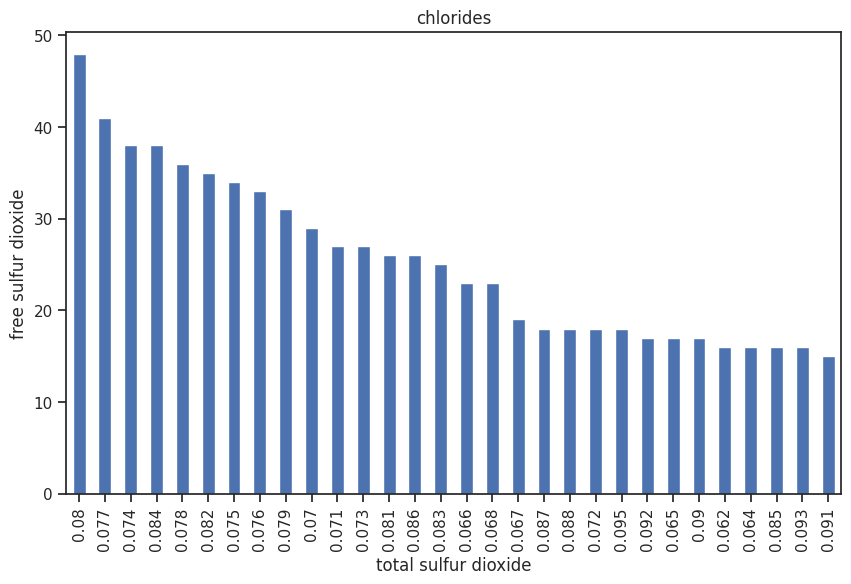

In [ ]:
#6. compute the measure of central tendency of the residual sugar column.
#Descriptive Statistics
#Calculate mean, median and mode of dat set residual sugar
mean = df["residual sugar"].mean()
median =df["residual sugar"].median()
mode = df["residual sugar"].mode()
print(mean , median, mode)

#7. First 30 largest values and draw a bar chart
df['chlorides'].value_counts().nlargest(30).plot(kind='bar', figsize=(10,6))
plt.title("chlorides")
plt.ylabel('free sulfur dioxide')
plt.xlabel('total sulfur dioxide')


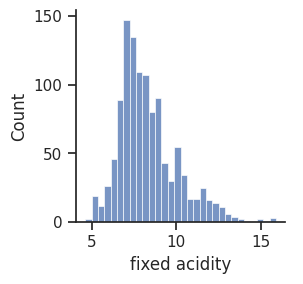

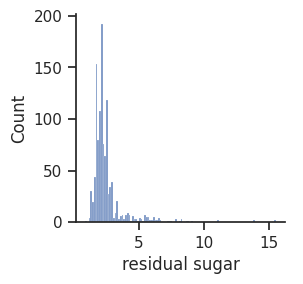

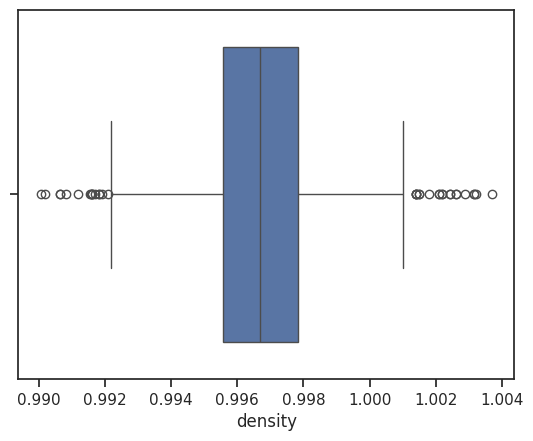

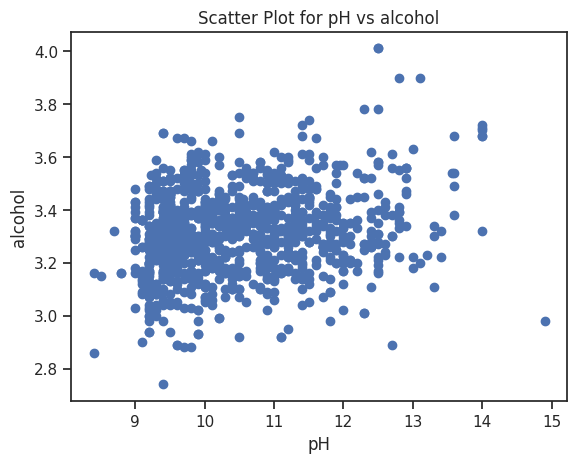

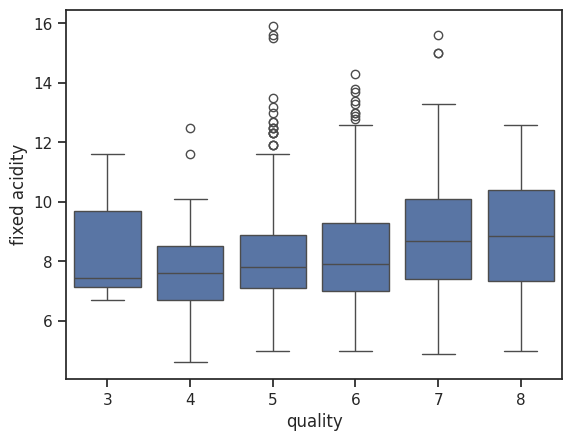

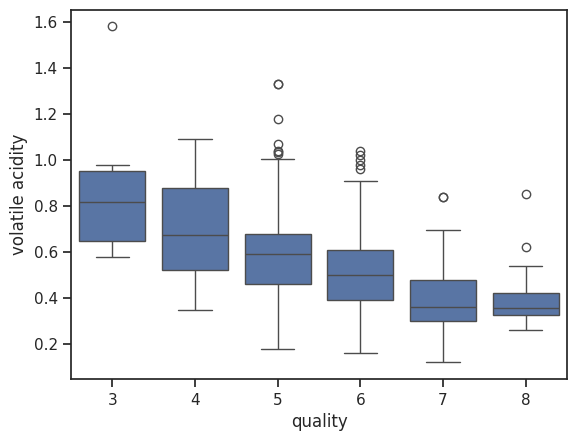

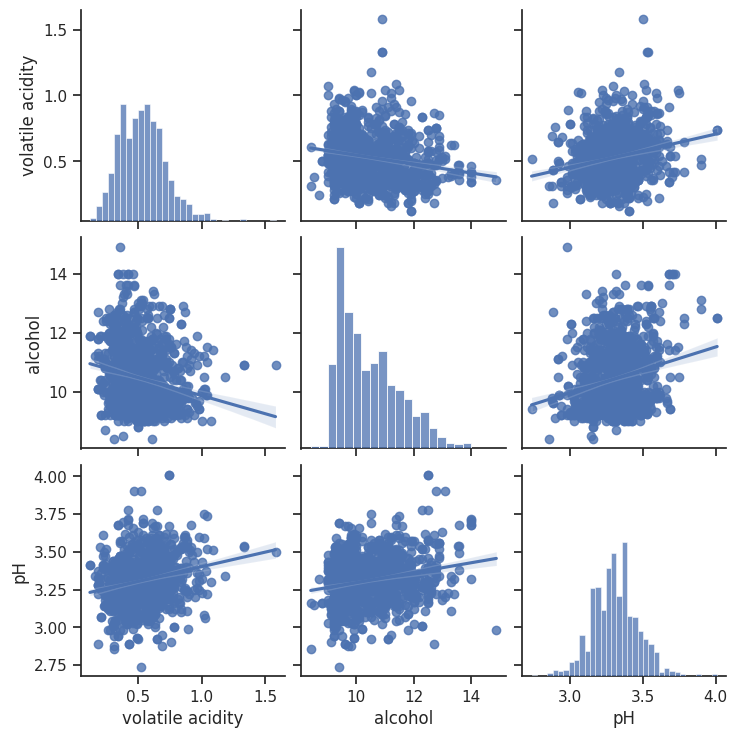

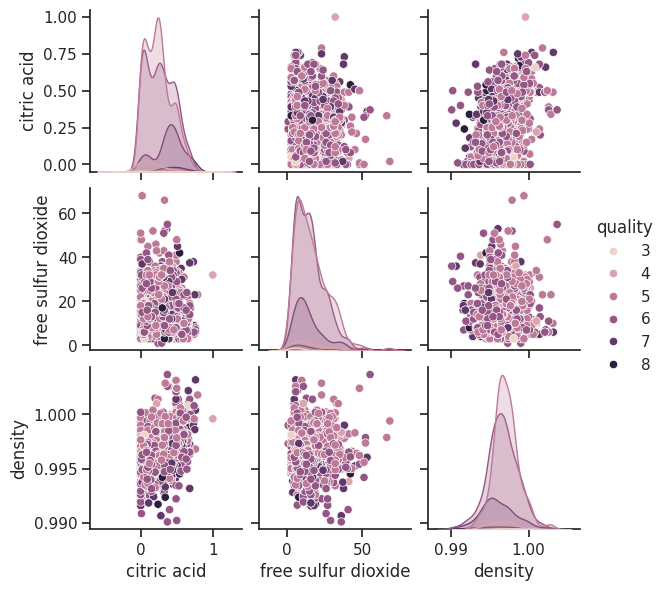

Pearson correlation between alcohol and pH:
p-value:	 1.2704383332771425e-14
cor:		 0.2253222028732469

Correlation Matrix:


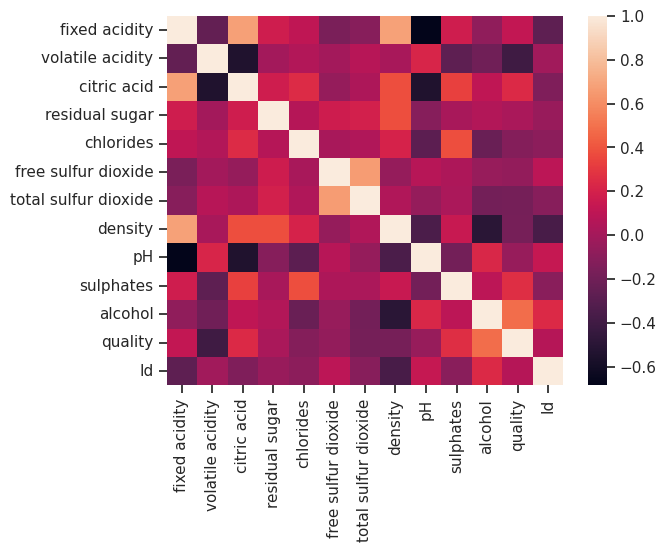

In [ ]:
#8. Distribution plot
import scipy.stats as stats
import matplotlib.pyplot as plt

# Distribution plots (using histplot instead of deprecated distplot)
sns.FacetGrid(df).map(sns.histplot,"fixed acidity").add_legend()
sns.FacetGrid(df).map(sns.histplot,"residual sugar").add_legend()
plt.show()

# Boxplot for a single variable
sns.boxplot(x="density",data=df)
plt.show()

# Scatter plot
plt.scatter(df["alcohol"], df["pH"])
plt.title("Scatter Plot for pH vs alcohol")
plt.xlabel("pH")
plt.ylabel("alcohol")
plt.show()

# Boxplots with two variables
sns.boxplot(x="quality",y="fixed acidity",data=df)
plt.show()
sns.boxplot(x="quality", y="volatile acidity",data=df)
plt.show()

# Pairplots
sns.pairplot(df,vars = ['volatile acidity', 'alcohol','pH'], kind="reg")
plt.show()
sns.set(style="ticks", color_codes=True)
sns.pairplot(df,height=2,vars = ['citric acid', 'free sulfur dioxide','density'], hue="quality")
plt.show()

# Correlation analysis
corr = stats.pearsonr(df["alcohol"], df["pH"])
print("Pearson correlation between alcohol and pH:")
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

correlation = df.corr(method='pearson', numeric_only=True)
print("\nCorrelation Matrix:")
correlation
sns.heatmap(correlation,xticklabels=correlation.columns,yticklabels=correlation.columns)
plt.show()